iter_bvp_Asplit.py is the following cell:

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(u, f, h, maxiter, tol = 1e-16): # We may add tolerance
    """Jacobi iteration for u'' = f on 1D grid."""
    m = len(u) - 2 # Number of inner points
    unew = u.copy()
    for _ in range(maxiter): # Stop criteria
        for i in range(1, m+1): # 1 to m, does not change extremes of u (boundary values)
            unew[i] = 0.5*(u[i-1] + u[i+1] - h**2 * f[i]) # Centered differences
        
        if np.max(np.abs(unew-u)) < tol: # Supremum error
            return unew
        u = unew.copy() # Copia los elementos, u = unew copia las direcciones de memoria
    return u

def gauss_seidel(u, f, h, maxiter, tol = 1e-16):
    """Gauss-Seidel iteration for u'' = f on 1D grid."""
    m = len(u) - 2
    for _ in range(maxiter):
        u_old = u.copy()
        for i in range(1, m+1):
            u[i] = 0.5*(u[i-1] + u[i+1] - h**2 * f[i])
        if np.max(np.abs(u_old-u)) < tol: # Supremum error
            return u
    return u

def sor(u, f, h, omega, maxiter, tol = 1e-16):
    """Successive Overrelaxation (SOR) iteration for u'' = f."""
    m = len(u) - 2
    for _ in range(maxiter):
        u_old = u.copy()
        for i in range(1, m+1):
            u_new = 0.5*(u[i-1] + u[i+1] - h**2 * f[i]) # GS from SOR
            u[i] = u[i] + omega*(u_new - u[i])
        if np.max(np.abs(u_old-u)) < tol: # Supremum error
            return u
    return u


# Exercises




## Exercise 1

The file `iter_bvp_Asplit.py` implements the Jacobi, Gauss-Seidel, and SOR matrix splitting methods for the 1D boundary value problem

$$
u''(x) = f(x), \quad a \le x \le b, \quad u(a) = \alpha, u(b) = \beta.
$$

In Python, students are asked to implement and test these methods.



### (a) Run the program for each method and produce a plot of error vs. number of iterations.

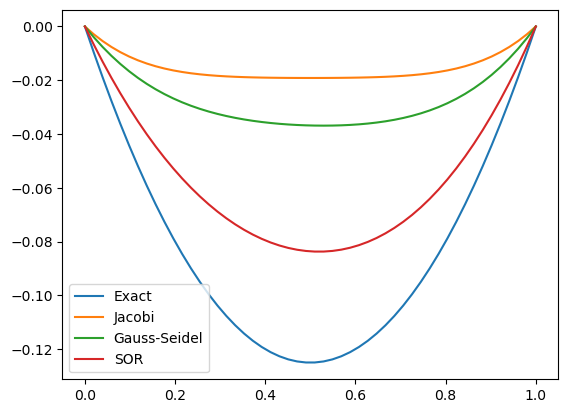

In [4]:

m = 50
x = np.linspace(0, 1, m+2)
h = x[1] - x[0]
f = np.ones_like(x)  # Example RHS: Function identically 1
u0 = np.zeros_like(x)
u0[0], u0[-1] = 0, 0  # Boundary conditions

# Exact function
u_exact_function = lambda t: t**2/2 - t/2

u_exact = u_exact_function(x)

u_jacobi = jacobi(u0.copy(), f, h, maxiter=100)
u_gs = gauss_seidel(u0.copy(), f, h, maxiter=100)
u_sor = sor(u0.copy(), f, h, omega=1.5, maxiter=100)

plt.plot(x, u_exact, label = "Exact")
plt.plot(x, u_jacobi, label = "Jacobi")
plt.plot(x, u_gs, label = "Gauss-Seidel")
plt.plot(x, u_sor, label = "SOR")

plt.legend(loc = "best")

plt.show()

Plot supremum errors:

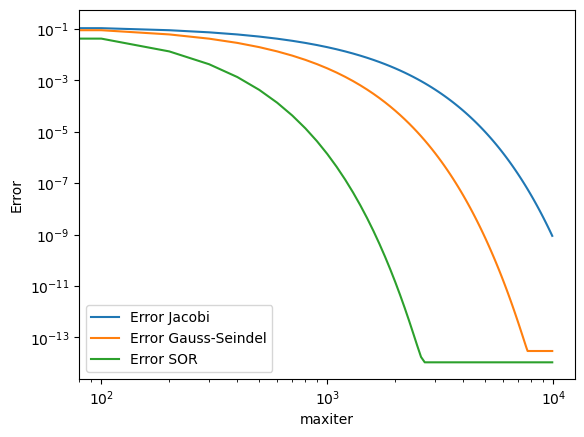

In [5]:
iters = [100*k for k in range(100)]

errors_Jacobi = []
errors_gs = []
errors_sor = []

for maxiter in iters:
    
    u_jacobi = jacobi(u0.copy(), f, h, maxiter=maxiter, tol = 1e-16)
    u_gs = gauss_seidel(u0.copy(), f, h, maxiter=maxiter, tol = 1e-16)
    u_sor = sor(u0.copy(), f, h, omega=1.5, maxiter=maxiter, tol = 1e-16)
    
    errors_Jacobi.append(np.max(np.abs(u_jacobi - u_exact)))
    errors_gs.append(np.max(np.abs(u_gs - u_exact)))
    errors_sor.append(np.max(np.abs(u_sor - u_exact)))
    
plt.loglog(iters, errors_Jacobi, label = "Error Jacobi")
plt.loglog(iters, errors_gs, label = "Error Gauss-Seindel")
plt.loglog(iters, errors_sor, label = "Error SOR")

plt.xlabel("maxiter")
plt.ylabel("Error")
plt.legend(loc = "best")

plt.show()


### (b) The convergence of SOR is very sensitive to the relaxation parameter $\omega$. Try $\omega = 1.8$ or $1.95$ and observe the effect.

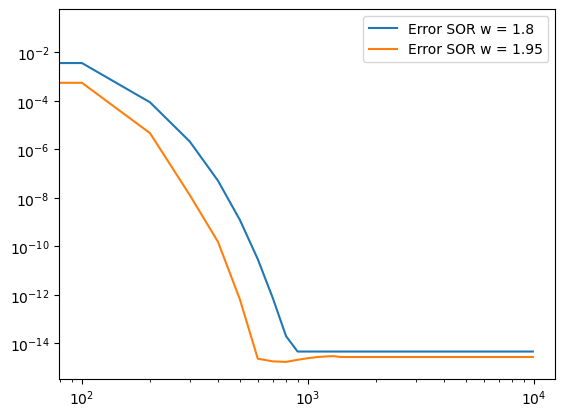

In [6]:
errors_18 = []
errors_195 = []

for maxiter in iters:
    
    u_18 = sor(u0.copy(), f, h, omega=1.8, maxiter=maxiter, tol = 1e-16)
    u_195 = sor(u0.copy(), f, h, omega=1.95, maxiter=maxiter, tol = 1e-16)
    
    errors_18.append(np.max(np.abs(u_18 - u_exact)))
    errors_195.append(np.max(np.abs(u_195 - u_exact)))
    

plt.loglog(iters, errors_18, label = "Error SOR w = 1.8")
plt.loglog(iters, errors_195, label = "Error SOR w = 1.95")

plt.legend(loc = "best")

plt.show()



### (c) Let
$$
g(\omega) = \rho(G(\omega))
$$

be the spectral radius of the iteration matrix $G$ for a given $\omega$. Write a program to plot $g(\omega)$ for $0 < \omega \le 2$.



### (d) Do **not** implement SOR as

```python
for iter in range(maxiter):
    uGS = np.linalg.solve(DA - LA, UA @ u + rhs)
    u = u + omega * (uGS - u)
```

Explain why this does not work and implement the correct line-by-line SOR update.



Students should complete the plotting, error computation, and SOR spectral radius analysis.


## Exercise 2

Solve the 2D Poisson problem

$$
\nabla^2 u(x,y) = f(x,y), \quad (x,y) \in [-1,1]\times[-1,1], \quad u|_{\partial \Omega} = g(x,y),
$$

with exact solution

$$
u(x,y) = e^x \sin(\pi y)
$$

using the 5-point finite difference stencil. Set $m=n=39$ ($h=1/20$), and tolerance $10^{-5}$. Implement Jacobi, Gauss-Seidel, and SOR in Python. Plot iteration count vs method and study effect of $\omega$ on SOR convergence.


In [7]:
def jacobi_5point(u, f, h, maxiter, tol = 1e-16):
    """Jacobi iteration for u'' = f on 2D grid.
    
    u is assumed to satisfy the BCs.
    Same h for both axis.
    """
    m = len(u) - 2 # Number of inner points for x and y
    unew = u.copy()
    for _ in range(maxiter): # Stop criteria
        for j in range(1, m+1):
            for i in range(1, m+1): # 1 to m, does not change extremes of u (boundary values)
                unew[i, j] = 0.25*(u[i-1, j] + u[i+1, j] + u[i, j-1] + u[i, j+1] - h**2 * f[i, j]) # Centered differences
        
        if np.max(np.abs(unew-u)) < tol: # Supremum error
            return unew
        u = unew.copy() # Copia los elementos, u = unew copia las direcciones de memoria
    return u


def gs_5point(u, f, h, maxiter, tol = 1e-16):
    """Gauss-Seidel  iteration for u'' = f on 2D grid using a 5 point stencil.
    
    u is assumed to satisfy the BCs.
    Same h for both axis.
    """
    m = len(u) - 2 # Number of inner points for x and y
    
    for _ in range(maxiter): # Stopping criteria
        u_old = u.copy()
        for j in range(1, m+1):
            for i in range(1, m+1): # 1 to m, does not change extremes of u (boundary values)
                u[i, j] = 0.25*(u[i-1, j] + u[i+1, j] + u[i, j-1] + u[i, j+1] - h**2 * f[i, j]) # Centered differences
        
        if np.max(np.abs(u_old-u)) < tol: # Supremum error
            return u
    return u


def sor_5point(u, f, h, omega, maxiter, tol = 1e-16):
    """Successive Overrelaxation (SOR) iteration for u'' = f."""
    m = len(u) - 2
    for _ in range(maxiter):
        u_old = u.copy()
        for i in range(1, m+1):
            for j in range(1, m+1):
                u_new = 0.25*(u[i-1, j] + u[i+1, j] + u[i, j-1] + u[i, j+1] - h**2 * f[i, j]) # GS from SOR
                u[i, j] = u[i, j] + omega*(u_new - u[i, j]) # SOR
        if np.max(np.abs(u_old-u)) < tol: # Supremum error
            return u
    return u


Example:

In [8]:

h= 1/20
m = 39

x = np.linspace(-1, 1, m+2)
y = np.linspace(-1, 1, m+2)

u_exact = lambda x, y: np.exp(x)*np.sin(np.pi*y)

# f is the Laplacian.
# fxx = u_exact
# fyy = - pi**2 * u_exact

f = lambda x, y: (1-np.pi**2)*u_exact(x,y)


sol = np.zeros((m+2, m+2))

for i in range(m+2):
    sol[i, :] = u_exact(x[i], y) # Element -1 not included in y[1:-1]
    
print(f"sol.shape = {sol.shape}")
# print(f"sol = {sol}")



rhs = np.zeros((m+2, m+2))

for i in range(1, m+1):
    # borders are 0 bc do not affect BCs
    rhs[i, 1:-1] = f(x[i+1], y[1:-1]) # Element -1 not included in y[1:-1]. i+1 to not include Boundary points
    
print(f"rhs.shape = {rhs.shape}")
print(f"rhs = {rhs}")

u0_5point = np.zeros((m+2,m+2)) # Include BCs

# BCs

u0_5point[0, :] = u_exact(-1, y)
u0_5point[-1, :] = u_exact(1, y)
u0_5point[:, 0] = u_exact(x, -1)
u0_5point[:, -1] = u_exact(x, 1)

# print(u)


sol.shape = (41, 41)
rhs.shape = (41, 41)
rhs = [[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.56412021  1.11434991 ... -1.11434991 -0.56412021
   0.        ]
 [ 0.          0.59304327  1.17148385 ... -1.17148385 -0.59304327
   0.        ]
 ...
 [ 0.          3.58770271  7.08706428 ... -7.08706428 -3.58770271
   0.        ]
 [ 0.          3.77164817  7.45042584 ... -7.45042584 -3.77164817
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]


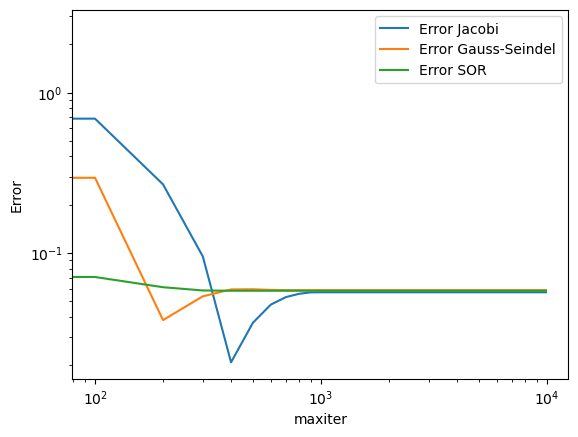

In [12]:

iters = [100*k for k in range(100)]

errors_Jacobi = []
errors_gs = []
errors_sor = []

for maxiter in iters:
    
    u_jacobi = jacobi_5point(u0_5point.copy(), rhs, h, maxiter=maxiter, tol = 1e-5)
    u_gs = gs_5point(u0_5point.copy(), rhs, h, maxiter=maxiter, tol = 1e-5)
    u_sor = sor_5point(u0_5point.copy(), rhs, h, omega=1.5, maxiter=maxiter, tol = 1e-5) # omega = 1 is GS to check
    
    errors_Jacobi.append(np.max(np.abs(u_jacobi - sol)))
    errors_gs.append(np.max(np.abs(u_gs - sol)))
    errors_sor.append(np.max(np.abs(u_sor - sol)))
    
plt.loglog(iters, errors_Jacobi, label = "Error Jacobi")
plt.loglog(iters, errors_gs, label = "Error Gauss-Seindel")
plt.loglog(iters, errors_sor, label = "Error SOR")

plt.xlabel("maxiter")
plt.ylabel("Error")
plt.legend(loc = "best")

plt.show()
